# 선형회귀 vs 로지스틱 회귀 vs 퍼셉트론

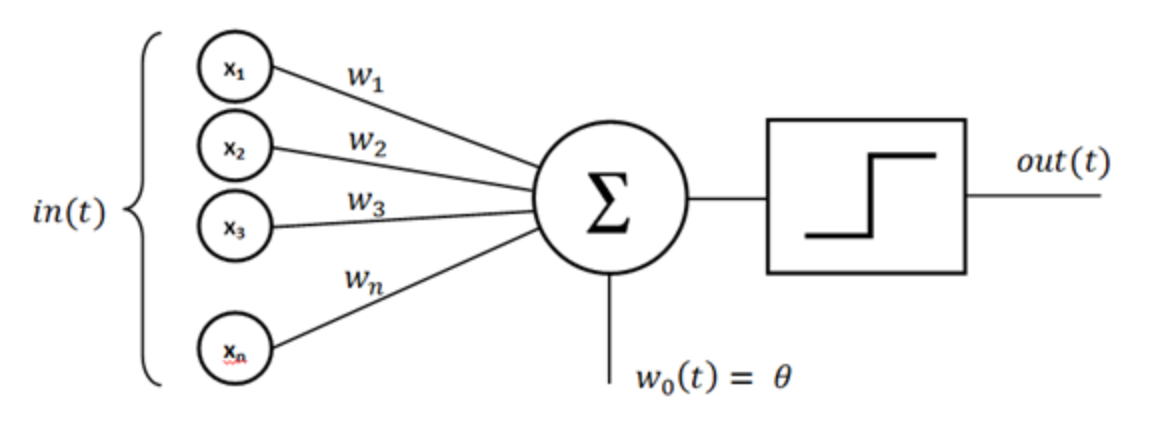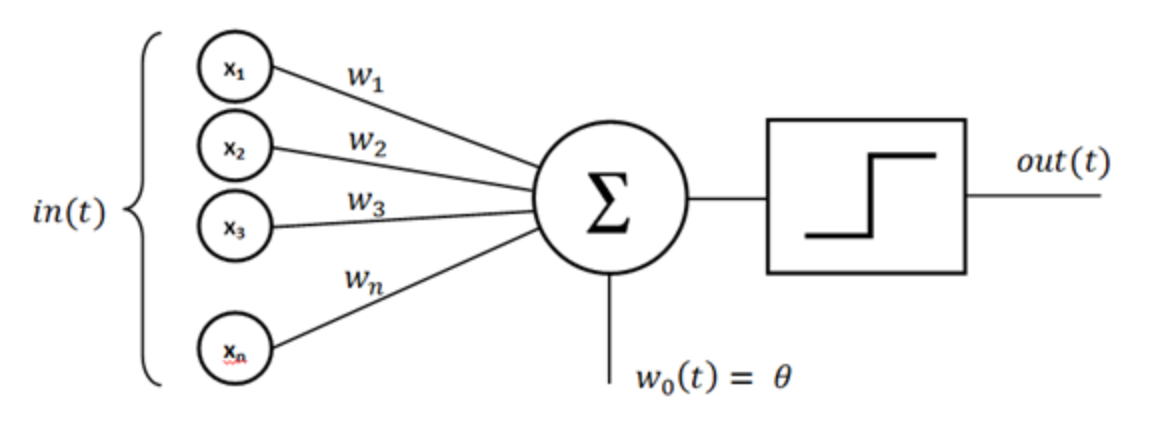

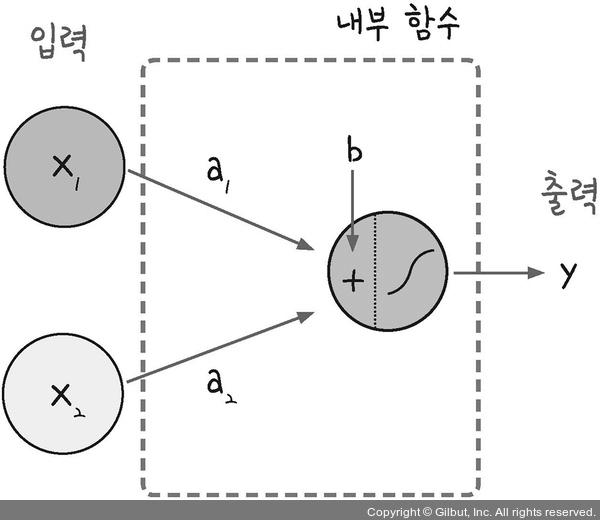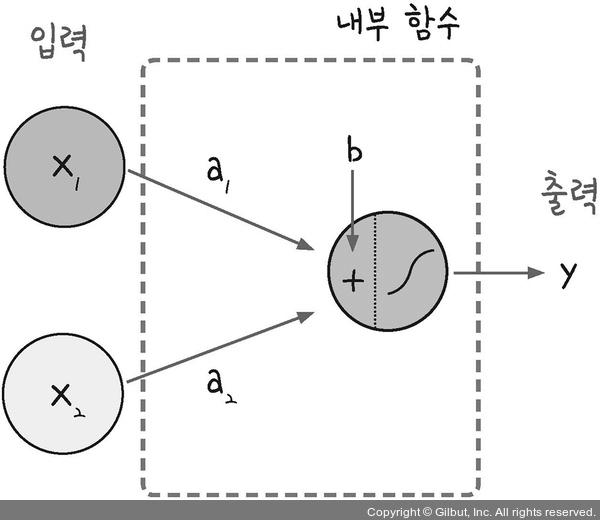

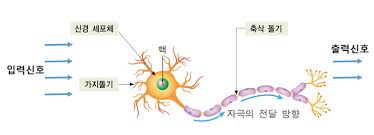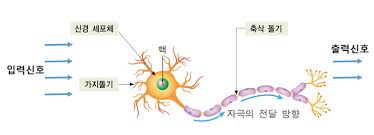

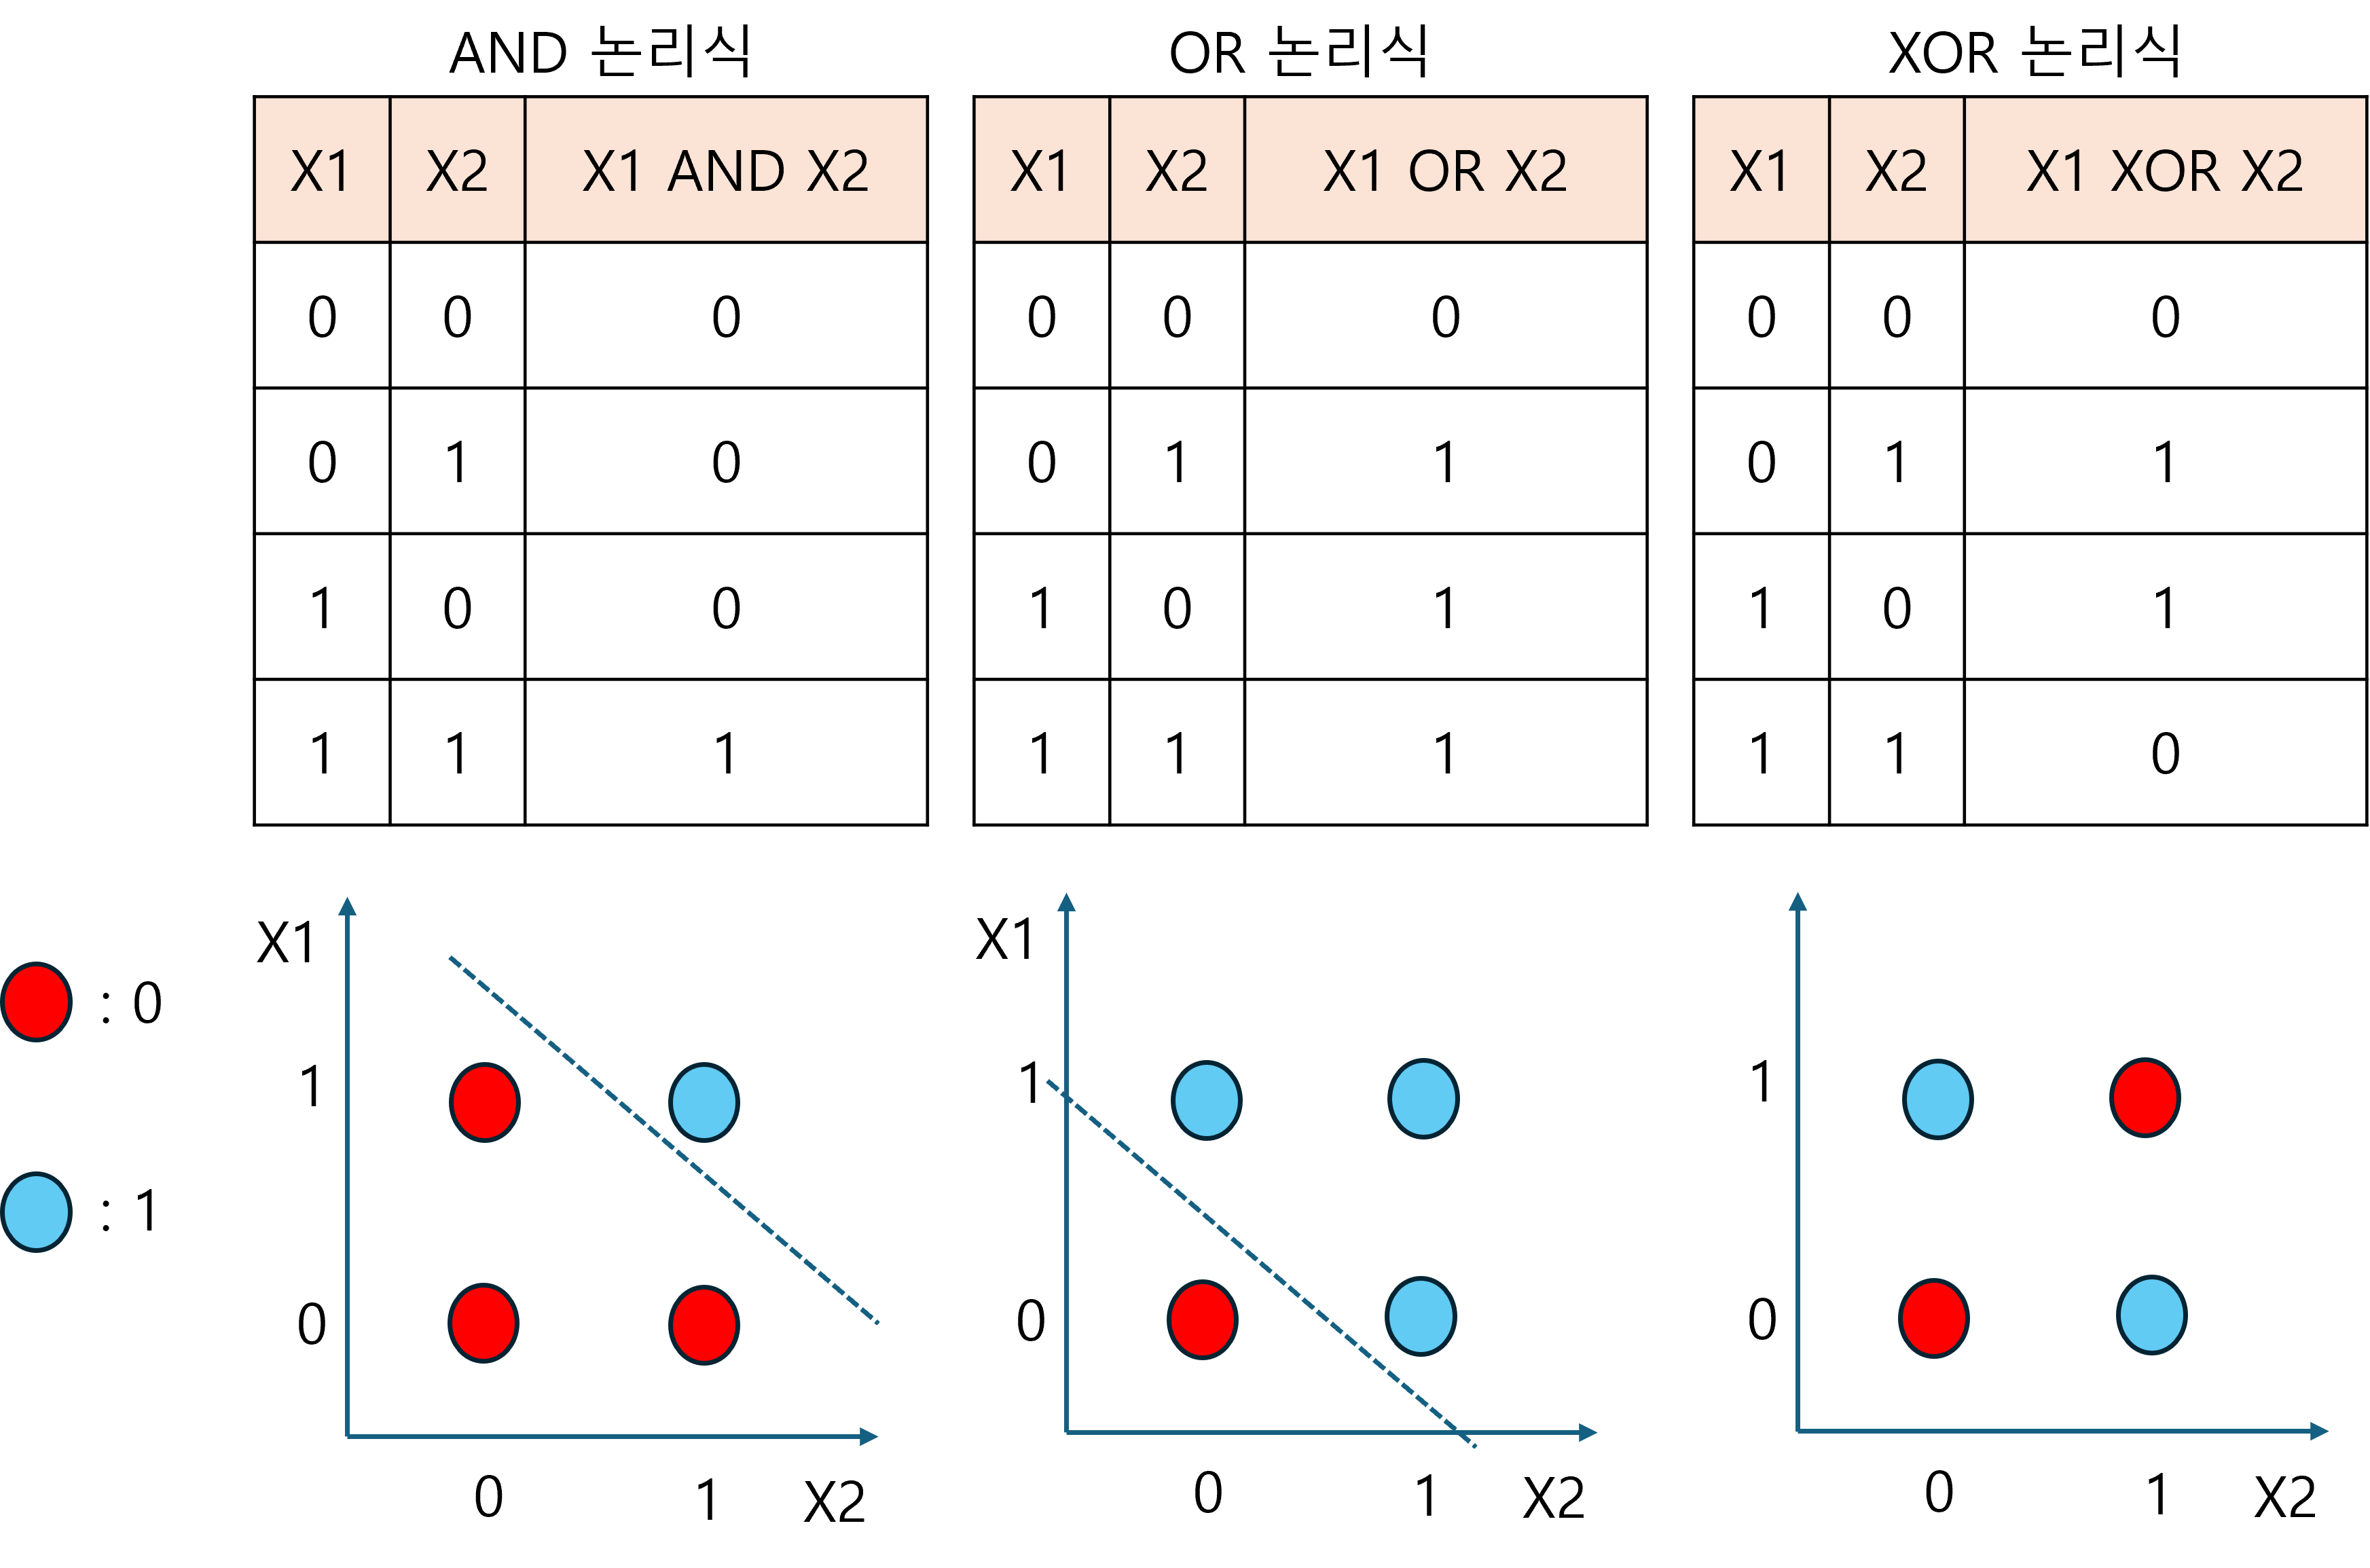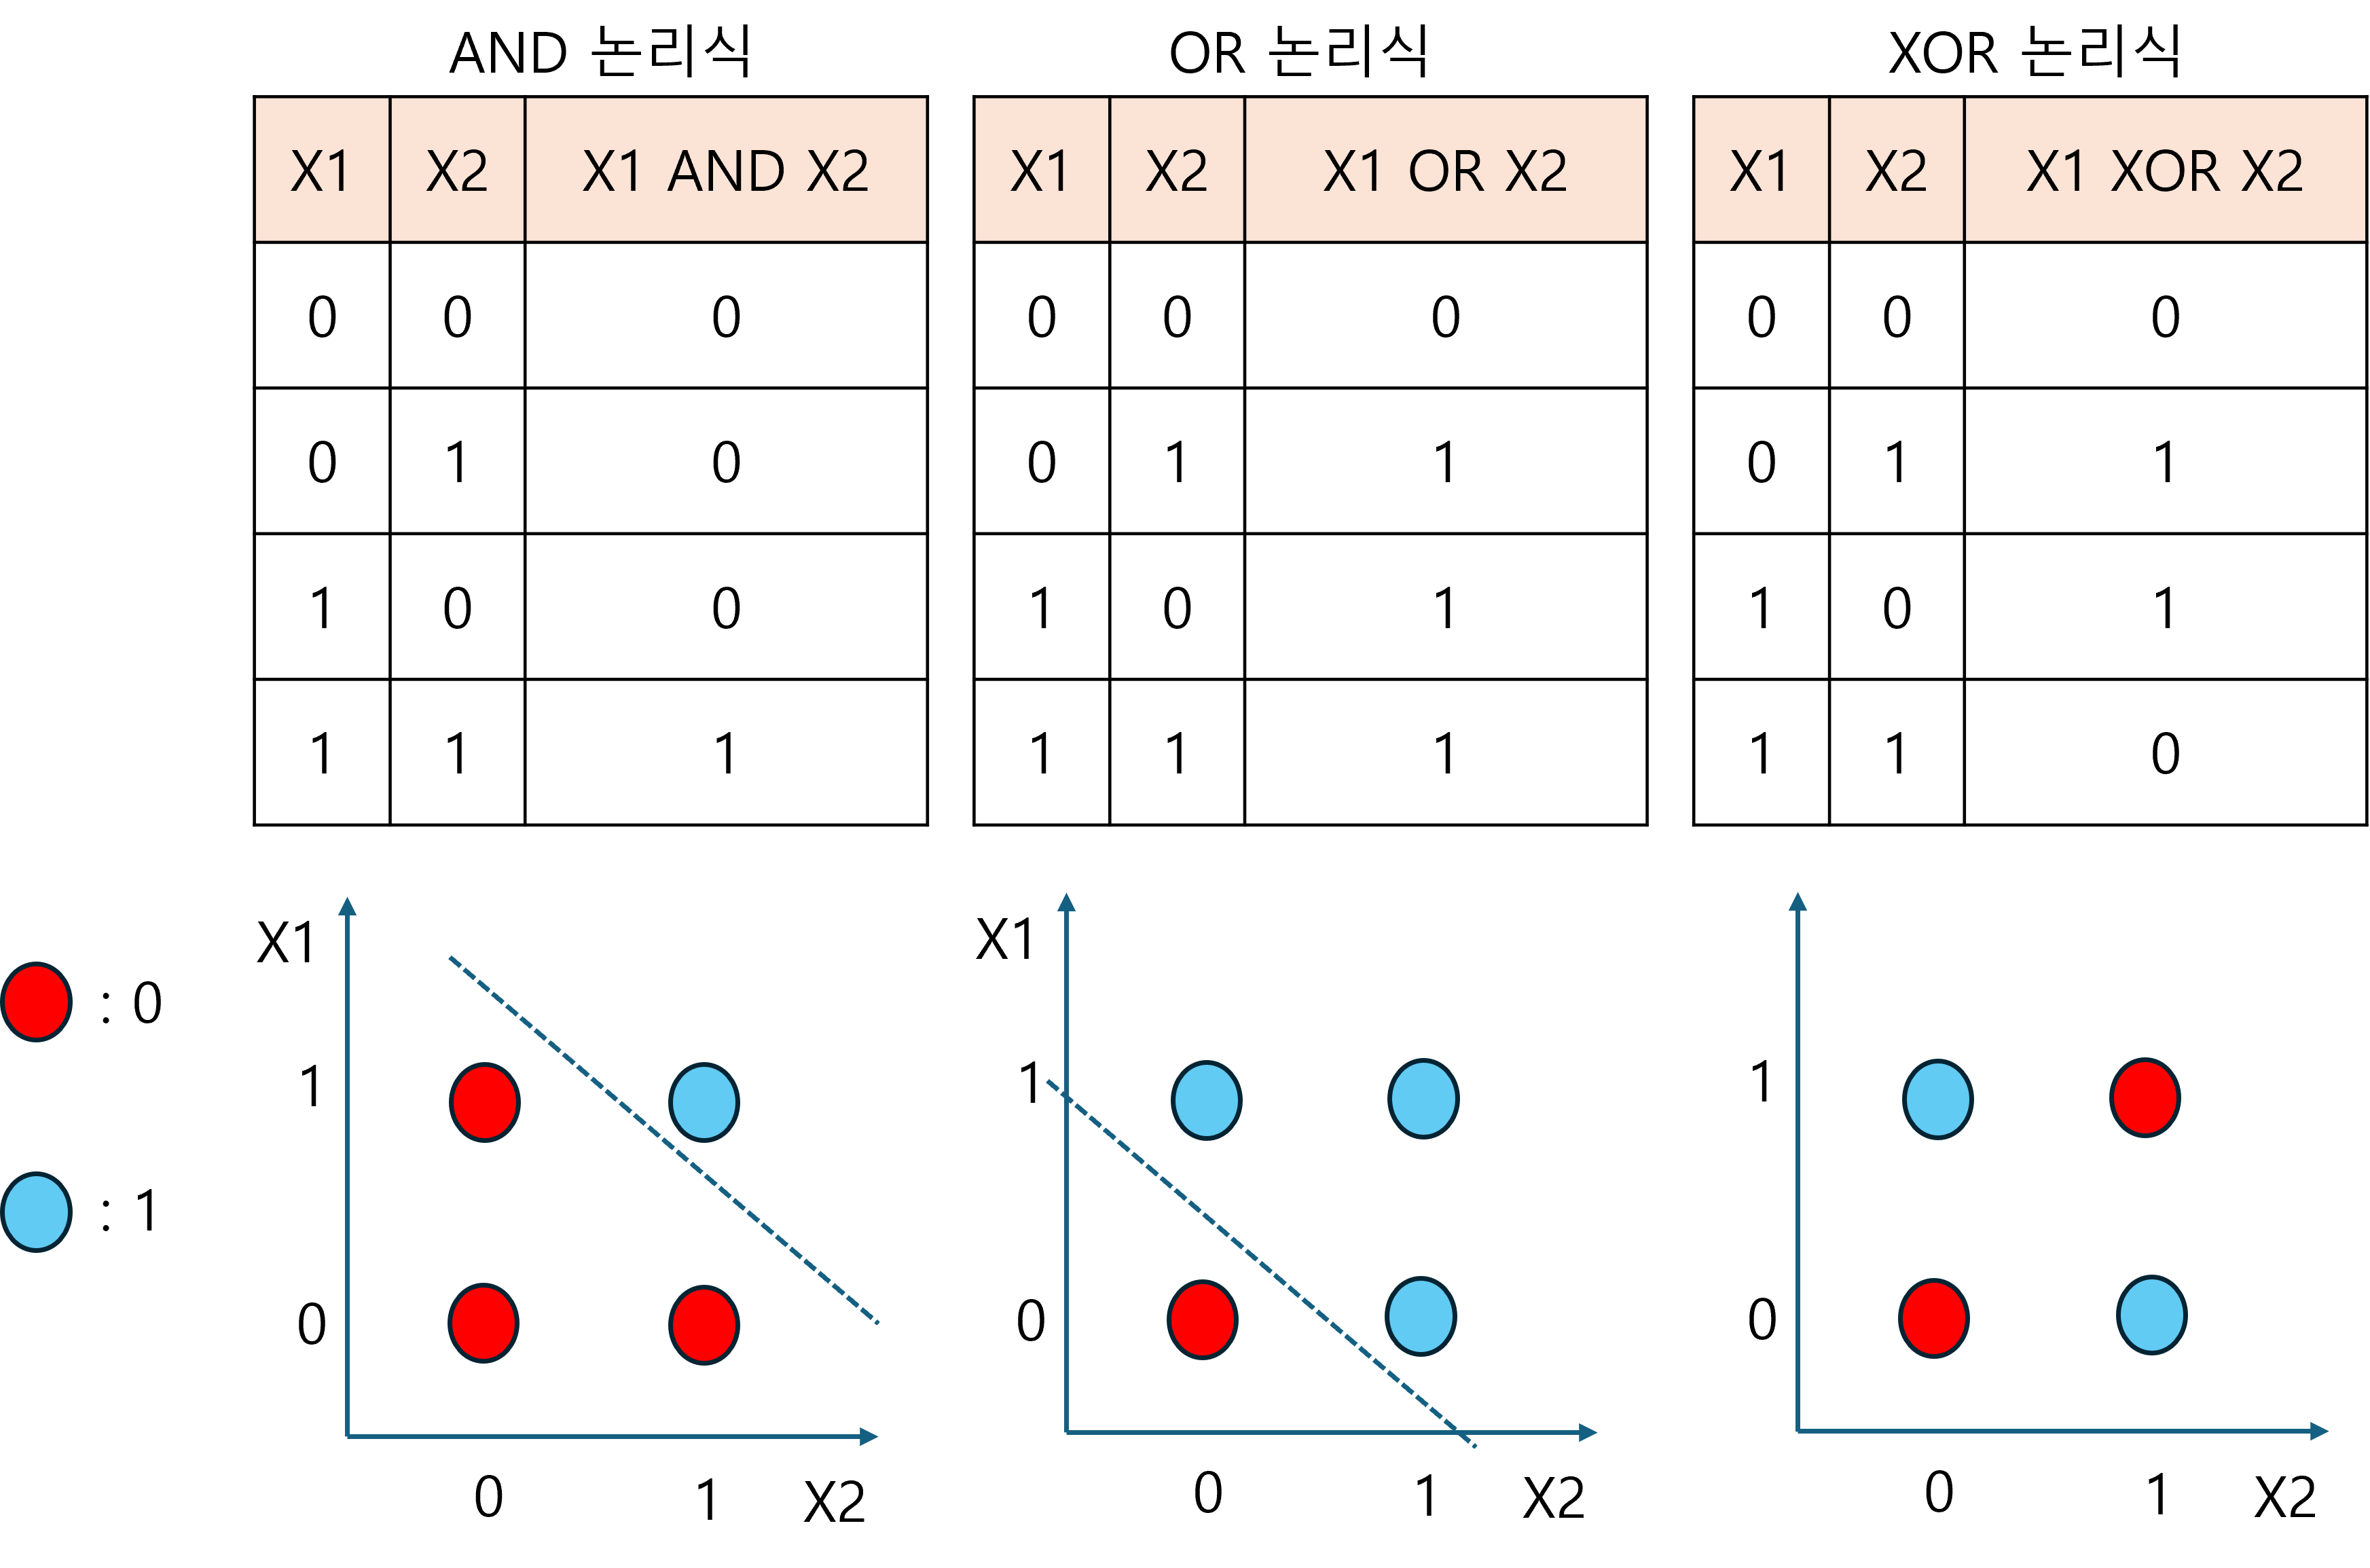

# XOR 문제 때문에 -> 1차 빙하기가 찾아옴
# 결국 문제를 해결하는데 -> 다층퍼셉트론 (MLP : Multi Layer Perceptron)

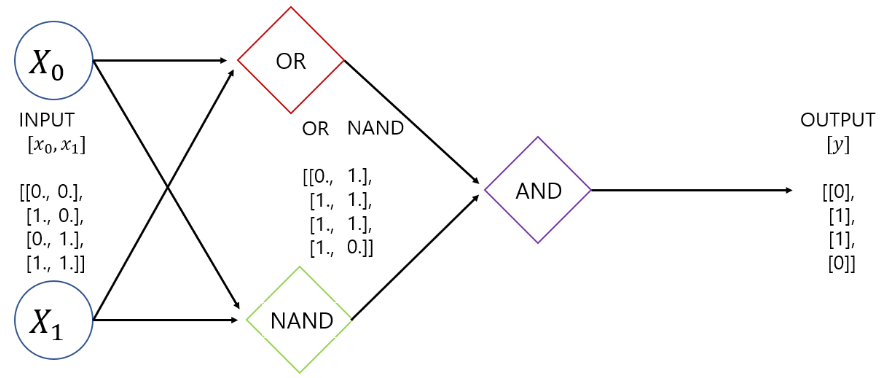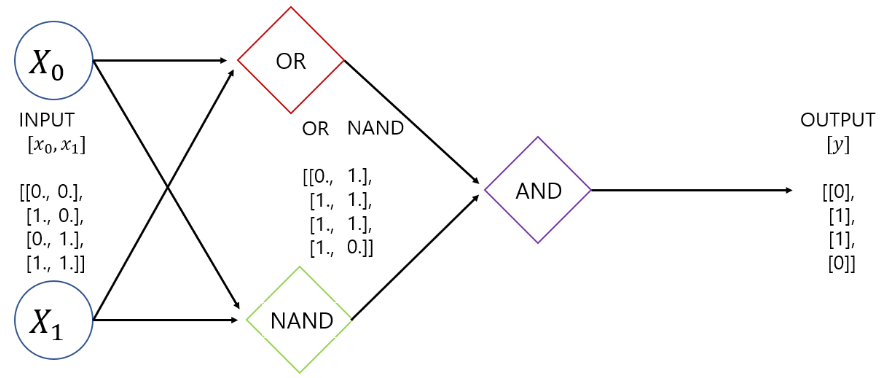

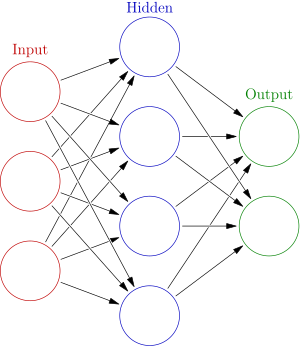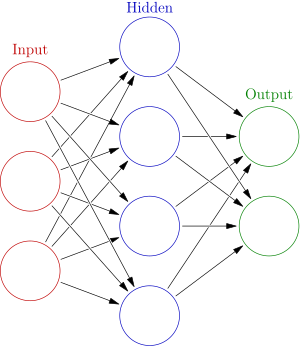

# 생각보다 되게 간단 -> 이게 실제로 먹힐까?

# Universal Approximation Proxmity 증명 (보편 근사 정리)
-> 어떤 신경망이든 노드(동그라미)가 충분하다면 -> 어떤 함수던 모방할 수 있다

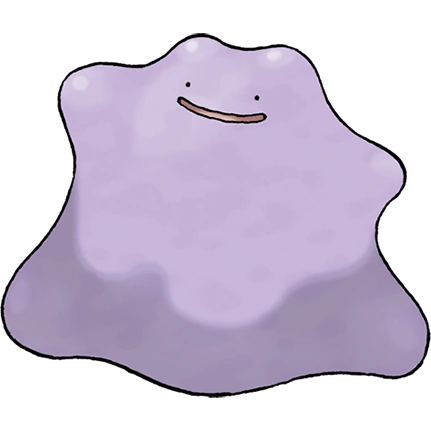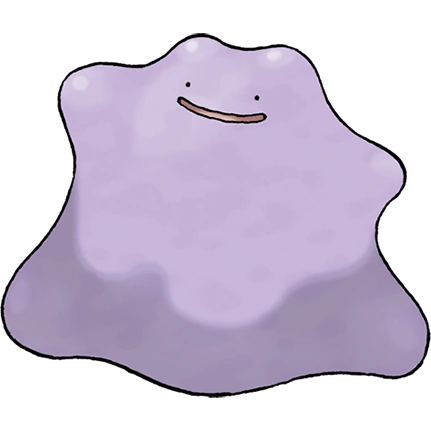

# 딥러닝으로 회귀하기

In [29]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 데이터 로드
X, y = fetch_california_housing(return_X_y=True)

# 데이터 분할 -> 제일 좋은 거는 아예 분석을 시작하시기 전에 분리하면 가장 좋음 (실무 느낌이 남)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# EDA, 가설검정

# 꼭 필요한 전처리 -> 결측값 처리, 스케일링 (min-max normalization, standardization)
# 스케일링 (신경망은 스케일링 중요)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MLP 회귀 모델 정의
mlp_reg = MLPRegressor(hidden_layer_sizes=(64, 32), 
                       activation='relu', 
                       solver='adam', 
                       max_iter=500,
                       verbose=True,
                       random_state=42)

# 학습
mlp_reg.fit(X_train, y_train)

# 예측 및 평가
y_pred = mlp_reg.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Iteration 1, loss = 1.15905607
Iteration 2, loss = 0.32990300
Iteration 3, loss = 0.26070940
Iteration 4, loss = 0.22816205
Iteration 5, loss = 0.21083194
Iteration 6, loss = 0.20145919
Iteration 7, loss = 0.19417870
Iteration 8, loss = 0.18773001
Iteration 9, loss = 0.18399713
Iteration 10, loss = 0.18033641
Iteration 11, loss = 0.17684878
Iteration 12, loss = 0.17478479
Iteration 13, loss = 0.17249104
Iteration 14, loss = 0.17020556
Iteration 15, loss = 0.16839861
Iteration 16, loss = 0.16629902
Iteration 17, loss = 0.16371351
Iteration 18, loss = 0.16180617
Iteration 19, loss = 0.16121245
Iteration 20, loss = 0.16013217
Iteration 21, loss = 0.15983571
Iteration 22, loss = 0.15652474
Iteration 23, loss = 0.15618266
Iteration 24, loss = 0.15367051
Iteration 25, loss = 0.15259863
Iteration 26, loss = 0.15360864
Iteration 27, loss = 0.15072556
Iteration 28, loss = 0.15254420
Iteration 29, loss = 0.15185657
Iteration 30, loss = 0.14795893
Iteration 31, loss = 0.14689132
Iteration 32, los

# 딥러닝으로 분류하기

In [13]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 데이터 로드
X, y = load_iris(return_X_y=True)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MLP 분류 모델 정의
mlp_clf = MLPClassifier(hidden_layer_sizes=(50, 30), 
                        activation='relu',
                        solver='adam',
                        max_iter=500,
                        verbose = True,
                        random_state=42)

# 학습
mlp_clf.fit(X_train, y_train)

# 예측 및 평가
y_pred = mlp_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Iteration 1, loss = 1.16455616
Iteration 2, loss = 1.14232720
Iteration 3, loss = 1.12082100
Iteration 4, loss = 1.09987301
Iteration 5, loss = 1.07952318
Iteration 6, loss = 1.05980575
Iteration 7, loss = 1.04066534
Iteration 8, loss = 1.02211752
Iteration 9, loss = 1.00404727
Iteration 10, loss = 0.98656902
Iteration 11, loss = 0.96965050
Iteration 12, loss = 0.95323829
Iteration 13, loss = 0.93724836
Iteration 14, loss = 0.92162052
Iteration 15, loss = 0.90638329
Iteration 16, loss = 0.89150874
Iteration 17, loss = 0.87692730
Iteration 18, loss = 0.86273885
Iteration 19, loss = 0.84883279
Iteration 20, loss = 0.83512323
Iteration 21, loss = 0.82159005
Iteration 22, loss = 0.80828873
Iteration 23, loss = 0.79516568
Iteration 24, loss = 0.78219562
Iteration 25, loss = 0.76938233
Iteration 26, loss = 0.75669386
Iteration 27, loss = 0.74413574
Iteration 28, loss = 0.73168871
Iteration 29, loss = 0.71943927
Iteration 30, loss = 0.70735995
Iteration 31, loss = 0.69548300
Iteration 32, los

### 더 넣어볼 수 있는 하이퍼파라미터

- activattion
    - 'relu'
    - 'tanh'
    - 'logistic'
- solver
    - 'adam' : 빠르고 안정적 (기본값)
    - 'lbfgs' : 작은 데이터셋에서 좋음
    - 'sgd' : 학습률 튜닝 필요, 대규모 데이터에 적합
- learning_rate_init(학습율)
    - 기본값 -> 0.001 (0.001~0.01 사이에서 조절하는 것을 권장, 경우에 따라 0.00001까지 가기도)
    - 너무 크면 발산, 너무 작으면 매우 느린 수렴 (local minimum 문제도 발생)
- alpha (L2 규제)
    - 기본값 -> 0.0001
    - 값이 클 수록 과적합 억제 경향이 강해짐, 근데 너무 강해지면 underfitting의 위험
- max_iter (최대 반복 횟수)
- learning_rate (학습율 스케줄링 방식)
    - 'constant' : 고정된 학습율 (기본값)
    - 'invscaling' : 점점 감소
    - 'adaptive' : 개선이 없을 때 감소
- early_stopping (자동 조기 종료)
    - True로 설정하면 작동함
- validation_fraction (validation 데이터 자동으로 분리)
    - 0.1 이런식으로 숫자를 지정하면 그만큼 생성되서 평가를 진행

In [14]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # 은닉층 3개
    activation='relu',                # 활성화 함수
    solver='adam',                    # 옵티마이저
    max_iter=500,
    random_state=42
)

# GrdSearch를 딥러닝에 적용한다면? (회귀)

In [8]:
from sklearn.model_selection import GridSearchCV

In [26]:
# 데이터 로드
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 모델 정의
mlp = MLPRegressor(max_iter=5, verbose=True, random_state=42)

# 파라미터 그리드
param_grid = {
    'hidden_layer_sizes': [(64,), (128,64), (128,64,32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'lbfgs'],
    'learning_rate_init': [0.001, 0.01]
}

# GridSearchCV
grid = GridSearchCV(mlp, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=3)
grid.fit(X_train, y_train)

print("최적 하이퍼파라미터:", grid.best_params_)
print("CV 평균 R²:", grid.best_score_)

# 최적 모델 평가
best_mlp = grid.best_estimator_
y_pred = best_mlp.predict(X_test)
print("테스트 R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Iteration 1, loss = 0.29408745
Iteration 2, loss = 0.18258618
Iteration 3, loss = 0.17010833
Iteration 4, loss = 0.16400688
Iteration 5, loss = 0.15708706
최적 하이퍼파라미터: {'activation': 'tanh', 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.01, 'solver': 'adam'}
CV 평균 R²: 0.7571084381992009
테스트 R²: 0.7536055076156115
MSE: 0.3228775550096117


C:\Users\sju12\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


# GrdSearch를 딥러닝에 적용한다면? (분류)

In [27]:
# 데이터 로드 및 분할
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MLP 모델
mlp = MLPClassifier(max_iter=5, verbose=True, random_state=42)

# 탐색할 하이퍼파라미터 설정
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate_init': [0.001, 0.01]
}

# GridSearchCV 구성
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=5,              # 5-Fold 교차검증
    scoring='accuracy',
    n_jobs=-1,         # 병렬 처리
    verbose=3
)

# 학습
grid_search.fit(X_train, y_train)

# 결과 출력
print("최적 하이퍼파라미터:", grid_search.best_params_)
print("최적 CV 점수:", grid_search.best_score_)

# 테스트 데이터로 평가
best_model = grid_search.best_estimator_
print("테스트 정확도:", best_model.score(X_test, y_test))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Iteration 1, loss = 1.08946168
Iteration 2, loss = 0.44367775
Iteration 3, loss = 0.33208374
Iteration 4, loss = 0.27172146
Iteration 5, loss = 0.22097492
최적 하이퍼파라미터: {'activation': 'tanh', 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.01, 'solver': 'adam'}
최적 CV 점수: 0.9333333333333333
테스트 정확도: 1.0


C:\Users\sju12\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
